In [38]:
import requests
import configparser
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from utils import plot_image
import numpy as np
from rasterio.io import MemoryFile
from datetime import datetime, timedelta
from sentinelhub import BBox, bbox_to_dimensions, CRS
from sentinelhub import SHConfig, SentinelHubCatalog, DataCollection
import evalscripts as eval
import pandas as pd
import os
import rasterio
from rasterio.io import MemoryFile

### Load config file and SHConfig

In [3]:
config_file = configparser.ConfigParser()
config_file.read("config.ini")

username = config_file["copernicus"]["username"]
password = config_file["copernicus"]["password"]

# Config file example:
# [copernicus]
# username = xyz@gmail.com
# password = 1234

In [4]:

config = SHConfig()

#https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/Authentication.html
# Dashboard > User settings > OAuth clients > Create

config.sh_client_id = config_file["copernicus"]["client_id"] #"<CLIENT ID>"
config.sh_client_secret = config_file["copernicus"]["client_secret"] #<CLIENT SECRET>"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token" # Is it required?
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.save("cdse")
# Saved config can be later accessed with config = SHConfig("cdse")

config = SHConfig("cdse")

### Function to get Bearer token

In [5]:
def get_access_token(username: str, password: str) -> str:

    data = {
        "client_id": "cdse-public",
        "username": username,
        "password": password,
        "grant_type": "password",
    }

    try:
        r = requests.post(
            "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
            data=data,
        )
        r.raise_for_status()
        access_token = r.json().get("access_token")
        if not access_token:
            raise ValueError("No access token found in response.")
        return access_token
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return None

# Retrieve the token
access_token = get_access_token(username, password)

### Function to get Copernicus data

In [7]:
def get_image_copernicus(access_token, time_interval, image_type, aoi, evalscript, resolution, config): 

    # Set identifier for the type of response
    if image_type == "png": 
        identifier = "default"
    elif image_type == "tiff":
        identifier = "index"

    # Set the url to sent the request
    url = "https://sh.dataspace.copernicus.eu/api/v1/process"

    # Define the Area of Interest
    aoi_bbox = BBox(bbox=aoi, crs=CRS.WGS84)
    aoi_size = bbox_to_dimensions(aoi_bbox, resolution=resolution)

    # Use SentinelHubCatalog to check if there are any images in the time interval of interest
    # If there are, extract the date (can't get it directly from the tiff)
    catalog = SentinelHubCatalog(config=config)
    date_range = time_interval[0],  time_interval[1]
    search_iterator = catalog.search(
        DataCollection.SENTINEL2_L2A,
        bbox=aoi_bbox,
        time= date_range ,
        fields={"include": ["id"], "exclude": [ "properties.datetime"]},
    )
    results = list(search_iterator)
    unique_results = {}
    for item in results:
        acquisition_id = item['id'].split('_T')[0]
        if acquisition_id not in unique_results:
            unique_results[acquisition_id] = item
    unique_results = list(unique_results.values())
    ids = [item['id'] for item in unique_results]
    dates = [datetime.strptime(id.split('_')[2][:8], "%Y%m%d").date() for id in ids]
    
    if len(dates) == 0: 
        print(f"Request empty for dates {time_interval}")
        return None, None

    else: 
        date_string = [d.isoformat() for d in dates][0]

        # Define the content for the post
        headers={
        "Content-Type": "application/json",
        "Authorization" : "Bearer "+ access_token
        }


        json={
            "input": {
                "bounds": {
                    "bbox": aoi
                },
                "data": [
                    {
                    "dataFilter": {
                        "timeRange": {
                        "from": time_interval[0] + "T00:00:00Z", #"2024-10-12T00:00:00Z", #YYYY-mm-dd
                        "to": time_interval[1] + "T23:59:59Z"#"2024-11-12T23:59:59Z"
                        },
                        "mosaickingOrder": "leastCC"
                    
                    },
                    "type": "sentinel-2-l2a"
                    }]
            },
            "output": {
                "width": aoi_size[0],#1271,
                "height": aoi_size[1],#2183

                "responses": [
                    {
                        "identifier": identifier,
                        "format": {
                            "type": "image/" + image_type
                        }
                    }
                ]
            },
            "evalscript" : evalscript
        }

        response = requests.post(url, headers=headers, json=json)

        if response.status_code == 200:
            print(f"Request completed for date {date_string} in interval {time_interval}")
            return response, date_string
        else:
            print(f"Request failed {response.content}")
            return None, None


### Use example #1. Basic evalscript to get array

In [21]:
# Si queremos una imagen de cada pasada, y sabemos que pasa cada 5 días, ponemos el timedelta como esos 5 días, y calculamos el n_chunks en función de eso
# Para definir los intervalos y cubrir todo el tiempo, hacemos dos listas, una para los principios, y otra para los finales
# de forma que no hay intersección entre los intervalos
start = datetime(2024, 1, 5)
end = datetime(2024, 1, 20)
tdelta = timedelta(days=5)
n_chunks = round((end - start)/tdelta)
starts = [(start + i * tdelta).date().isoformat() for i in range(n_chunks+1)]
ends = [(start + timedelta(days=4) + i * tdelta).date().isoformat() for i in range(n_chunks+1)]
slots = [(starts[i], ends[i]) for i in range(len(starts))]

# Método anterior: hacer n chunks entre las fechas que queramos
# start = datetime(2024, 1, 1)
# end = datetime(2024, 1, 31)
# n_chunks = 3
# tdelta = (end - start) / n_chunks
# edges = [(start + i * tdelta).date().isoformat() for i in range(n_chunks+1)]
# slots = [(edges[i], edges[i + 1]) for i in range(len(edges) - 1)]

In [18]:
access_token = get_access_token(username, password)
evalscript = """
    //VERSION=3

    function setup() {
        return {
            input: ["B03", "B08"],
            output: {
                id: "index",       // Identifier for the output
                bands: 1,
                sampleType: "FLOAT32"
            }
        }
    }

    function evaluatePixel(samples) {
        return [index(samples.B03, samples.B08)]
    }
    """
image_type = "tiff" # png para imagen / tiff para array - depende del evalscript
aoi = [-0.866977, 37.628916, -0.71696, 37.822802]
resolution = 10
for time_interval in slots:
    response, _ = get_image_copernicus(access_token, time_interval, image_type, aoi, evalscript, resolution, config)

Request completed for date 2021-01-05 in interval ('2021-01-01', '2021-01-05')
Request completed for date 2021-01-10 in interval ('2021-01-06', '2021-01-10')
Request completed for date 2021-01-15 in interval ('2021-01-11', '2021-01-15')
Request completed for date 2021-01-20 in interval ('2021-01-16', '2021-01-20')
Request completed for date 2021-01-25 in interval ('2021-01-21', '2021-01-25')


In [76]:
slots

[('2024-01-05', '2024-01-09'),
 ('2024-01-10', '2024-01-14'),
 ('2024-01-15', '2024-01-19'),
 ('2024-01-20', '2024-01-24')]

### Use example #2. Custom evalscript

In [25]:
access_token = get_access_token(username, password)

evalscript_custom = """
    //VERSION=3

    // CHANGE TO USE DIFFERENT INDEX
    // 0 = Chlorophyll a mg/m**3 | Range 0.9 - 28.1 | (https://custom-scripts.sentinel-hub.com/sentinel-2/mago_water_quality_monitoring_tool/) (Mishra 2012 Based on NDCI) 
    // 1 = Chlorophyll a for high values > 5 mg / m3 (Soria-Perpinyà 2021) | Range 5 - 675
    // 2 = Cyanobacteria (Phycocyanin) mg/m3 (Soria-Perpinyà 2021) | Range 0 - 1000
    // 3 = Turbidity NTU | Range 15 - 200
    // 4 = NDWI
    // 5 = NCDI (Normalized Difference Chlorophyll Index )
    // 6 = Chlorophyll a mg/m**3 (https://custom-scripts.sentinel-hub.com/sentinel-2/se2waq/)
    // 7 = NDVI
    // 8 = Chlorophyll a  low values < 5 mg / m3 (Soria-Perpinyà 2021) 

    var indexNumber = 8;
    
    // Change for range of the selected index. Adjust for higher or lower sensitivity after visual representation
    var minValue = 0;
    var maxValue = 30;

    
    // Color Scale
    var scaleLimits = [minValue, (maxValue + 3 * minValue) / 4, (maxValue + minValue) / 2, (3 * maxValue + minValue) / 4, maxValue] 
    // If min = 0  y max = 30: [0, 7.5, 15, 22.5, 30]. Points where color changes
    // For intermediate values colorBlend interpolates between the colors that surround the value
    var s = 255; 
    var colorScale =  // Colors mapped to  
    [
        [0 / s, 0 / s, 255 / s], // Blue
        [0 / s, 255 / s, 255 / s], // Cyan
        [0 / s, 255 / s, 0 / s], // Green
        [255 / s, 255 / s, 0 / s], // Yellow
        [255 / s, 0 / s, 0 / s], // Red
    ];
    var inverseColorScale =  // Inverse scale because for some indexes it makes more sense 
    [
        [255 / s, 0 / s, 0 / s], // Red
        [255 / s, 255 / s, 0 / s], // Yellow
        [0 / s, 255 / s, 0 / s], // Green
        [0 / s, 255 / s, 255 / s], // Cyan
        [0 / s, 0 / s, 255 / s], // Blue  
    ];


      
    function setup() {
        return {
            input: ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "SCL", "dataMask"],
            output: [
                { id: "default", bands: 3 },
                { id: "index", bands: 1, sampleType: "FLOAT32" },
                { id: "dataMask", bands: 1 }
            ]
        }
    }

    function evaluatePixel(samples) {

        // Initizalize 
        let imgVals = null;
        let val = NaN;

        // Filter to color only over water bodes: if NDWI is lower than 0 is not water, so return true color
        let NDWI = index(samples.B03, samples.B08); 
        let TrueColor = [samples.B04 * 2.5, samples.B03 * 2.5, samples.B02 * 2.5]; // Factor 2.5 to increase brightness

        // Apply NDWI filter only over these indexNumber's
        const applyNDWIFilter = [0, 1, 2, 3, 4, 5, 6, 8];

        // Indexes computed inside the switch no not all of them are calculated, only the one that we want
        if (applyNDWIFilter.includes(indexNumber) && NDWI < -0) { 
            imgVals = [...TrueColor, samples.dataMask]; // To get an array with R G B and mask to include validity information for eaxh pixel
        } else if (applyNDWIFilter.includes(indexNumber)) {
            switch (indexNumber) {
                case 0: 
                    let index0 = 14.039 + (86.11 * (samples.B05 - samples.B04) / (samples.B05 + samples.B04)) + (194.325 * Math.pow((samples.B05 - samples.B04) / (samples.B05 + samples.B04), 2));
                    let viz0 = colorBlend(index0, scaleLimits, colorScale);
                    imgVals = [...viz0, samples.dataMask];
                    val = index0;
                    break;
                case 1: 
                    let index1 = 19.866 * Math.pow(samples.B05 / samples.B04, 2.3051);
                    let viz1 = colorBlend(index1, scaleLimits, colorScale);
                    imgVals = [...viz1, samples.dataMask];
                    val = index1;
                    break;
                case 2: 
                    let index2 = 21.554 * Math.pow((samples.B05 / samples.B04), 3.47941);
                    let viz2 = colorBlend(index2, scaleLimits, colorScale);
                    imgVals = [...viz2, samples.dataMask];
                    val = index2;
                    break;
                case 3: 
                    let index3 = 194.79 * (samples.B05 * (samples.B05 / samples.B02)) + 0.9061;
                    let viz3 = colorBlend(index3, scaleLimits, colorScale);
                    imgVals = [...viz3, samples.dataMask];
                    val = index3;
                    break;
                case 4:
                    let index4 = index(samples.B03, samples.B08);
                    let viz4 = colorBlend(index4, scaleLimits, inverseColorScale);
                    imgVals = [...viz4, samples.dataMask];
                    val = index4;
                    break;
                case 5:
                    let index5 = index(samples.B05, samples.B04);
                    let viz5 = colorBlend(index5, scaleLimits, inverseColorScale);
                    imgVals = [...viz5, samples.dataMask];
                    val = index5;
                    break;
                case 6: 
                    let index6 = 4.26 * Math.pow(samples.B03/samples.B01, 3.94);
                    let viz6 = colorBlend(index6, scaleLimits, colorScale);
                    imgVals = [...viz6, samples.dataMask];
                    val = index6;
                    break;
                case 8: 
                    let index8 =  Math.pow(10, -2.4792 * Math.log10(Math.max(samples.B03, samples.B02) / samples.B03) - 0.0389);
                    let viz8 = colorBlend(index8, scaleLimits, colorScale);
                    imgVals = [...viz8, samples.dataMask];
                    val = index8;
                    break;
        }
        } else {
            switch (indexNumber) {
                case 7: 
                    let index7 = index(samples.B08, samples.B04);
                    let viz7 = colorBlend(index7, scaleLimits, inverseColorScale);
                    imgVals = [...viz7, samples.dataMask];
                    val = index7;
                    break;
            }
        }

        const indexVal = samples.dataMask === 1 ? val : NaN; // If the pixel is valid (dataMask = 1), value set as the val previously computed, if not, NaN to ignore the pixel

        return {
            default: imgVals,
            index: [indexVal],
            // eobrowserStats: [val, isCloud(samples.SCL) ? 1 : 0], // Add function isCloud si se va a dejar
            dataMask: [samples.dataMask]
        };
    }
    """


In [ ]:
image_type = "tiff" # png para imagen / tiff para array - depende del evalscript
start = datetime(2022, 7, 1).date().isoformat()
end = datetime(2022, 7, 20).date().isoformat()
time_interval = [start, end]
aoi = [-0.866977, 37.628916, -0.71696, 37.822802]
resolution = 10
response = get_image_copernicus(access_token, time_interval, image_type, aoi, evalscript, resolution, config)

In [38]:
if response.status_code == 200:
    # Open the TIFF data directly from the response content using a MemoryFile
    with MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            index_array = src.read(1)  # Read the first band as a NumPy array

    # Now `index_array` is a NumPy array containing the index values for each pixel
    print(index_array)
else:
    print(f"Request failed with status code: {response.status_code}")

[[192 200 177 ...   0   0   0]
 [153 190 176 ...   0   0   0]
 [171 189 178 ...   0   0   0]
 ...
 [169 194 174 ...  84  74  51]
 [130 151 128 ...  81  57  50]
 [ 99  97  95 ...  78  60  63]]


#### Representation

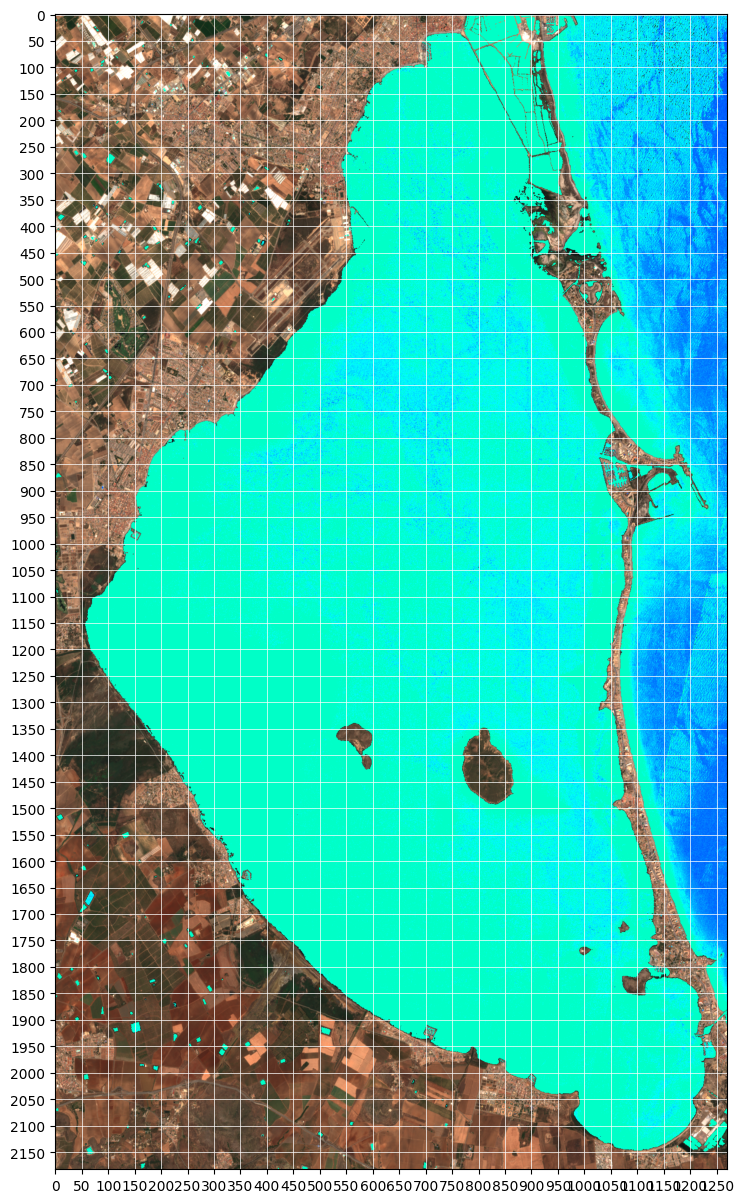

In [40]:
image = Image.open(BytesIO(response.content))
image_np = np.array(image, dtype=np.float32)  # Convert to float for scaling

# Use your `plot_image` function with a brightness factor and clipping range
plot_image(image_np, factor=1 / 255, clip_range=(-1, 1), grid_interval=50)

### Relate to bouy coordinates

In [8]:
image_type = "tiff" # png para imagen / tiff para array - depende del evalscript
start = datetime(2021, 8, 10).date().isoformat()
end = datetime(2021, 8, 20).date().isoformat()
time_interval = [start, end]
aoi = [-0.866977, 37.628916, -0.71696, 37.822802]
resolution = 10
access_token = get_access_token(username, password)
evalscript = eval.evalscript_ndwi_array
response, date_taken = get_image_copernicus(access_token, time_interval, image_type, aoi, evalscript, resolution, config)

Request completed for date 2021-08-18 in interval ['2021-08-10', '2021-08-20']


In [8]:
if response.status_code == 200:
    with MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            index_array = src.read(1) 
    #print(index_array)
else:
    print(f"Request failed with status code: {response.status_code}")

In [19]:
def coordenadas_a_pixel(response, lat, lon, buoy):
    """
    Extract pixel value and coordinates from a TIFF response using latitude and longitude.
    """
    if response.status_code == 200:
        # Read the TIFF content from the response
        with MemoryFile(response.content) as memfile:
            with memfile.open() as src:
                # Read the first band of the TIFF file
                index_array = src.read(1)  # Assuming single-band data
                
                # Get the pixel coordinates for the given latitude and longitude
                row, col = src.index(lon, lat)
                
                # Extract the value from the index array
                value = index_array[row, col]
                
                # Print for debugging
                print(f"Loc Buoy {buoy} - Pixel value: {value}, Latitude: {lat}, Longitude: {lon}")
                
                return row, col, value
    else:
        print(f"Request failed with status code: {response.status_code}")
        return None

#coordenadas_a_pixel(response, 37.718000, -0.839783, "CTD-7")

Loc Buoy CTD-7 - Pixel value: 0.19723182916641235, Latitude: 37.718, Longitude: -0.839783


(1179, 230, 0.19723183)

In [9]:
path = "../boyaUPCT"
filename = "locBoyasUPCT.csv"
loc_boyas = pd.read_csv(os.path.join(path, filename)).iloc[:,:3]
loc_boyas.head(3)

,CodPuntoControl,Latitud,Longitud
0,CTD-1,37.811800,-0.784483
1,CTD-2,37.760617,-0.807800
2,CTD-3,37.761783,-0.783550


In [17]:
def process_buoy_data(response, df):
    results = []

    for _, row in df.iterrows():
        buoy, lat, lon = row['CodPuntoControl'], row['Latitud'], row['Longitud']
        pixel_info = coordenadas_a_pixel(response, lat, lon, buoy)
        results.append((buoy, lat, lon, *pixel_info))
    return pd.DataFrame(results, columns=['Buoy', 'Latitude', 'Longitude', 'Row', 'Col', 'Pixel_Value'])

df_bouy_satellite = process_buoy_data(response, loc_boyas)

Loc Buoy CTD-1 - Pixel value: 0.1251489818096161, Latitude: 37.8118, Longitude: -0.784483
Loc Buoy CTD-2 - Pixel value: 0.06145251542329788, Latitude: 37.760617, Longitude: -0.8078
Loc Buoy CTD-3 - Pixel value: 0.14147521555423737, Latitude: 37.761783, Longitude: -0.78355
Loc Buoy CTD-4 - Pixel value: 0.06853582710027695, Latitude: 37.748233, Longitude: -0.749617
Loc Buoy CTD-5 - Pixel value: 0.2732919156551361, Latitude: 37.74045, Longitude: -0.727117
Loc Buoy CTD-6 - Pixel value: 0.10024449974298477, Latitude: 37.710417, Longitude: -0.778383
Loc Buoy CTD-7 - Pixel value: 0.19723182916641235, Latitude: 37.718, Longitude: -0.839783
Loc Buoy CTD-8 - Pixel value: 0.05526948347687721, Latitude: 37.694517, Longitude: -0.8104
Loc Buoy CTD-9 - Pixel value: 0.19955898821353912, Latitude: 37.666817, Longitude: -0.809683
Loc Buoy CTD-10 - Pixel value: 0.07456140220165253, Latitude: 37.659833, Longitude: -0.781967
Loc Buoy CTD-11 - Pixel value: 0.20000000298023224, Latitude: 37.6518, Longitude: 

In [13]:
def process_buoy_data_multiple_responses(slots, access_token, image_type, aoi, evalscript, resolution, config, loc_boyas):
    """Process buoy data for multiple time intervals and combine results."""
    all_results = []  # To store results from all time intervals

    for time_interval in slots:
        # Get the satellite response for the current time interval
        response, date_taken = get_image_copernicus(access_token, time_interval, image_type, aoi, evalscript, resolution, config)
        
        if response is None:
            print(f"No data available for time interval {time_interval}")
            continue 

        if response.status_code == 200:
            results = []
            for _, row in loc_boyas.iterrows():
                buoy, lat, lon = row['CodPuntoControl'], row['Latitud'], row['Longitud']
                pixel_info = coordenadas_a_pixel(response, lat, lon, buoy)
                results.append((time_interval, date_taken, buoy, lat, lon, *pixel_info))

            all_results.extend(results)
        else:
            print(f"Failed to retrieve data for time interval {time_interval}: Status code {response.status_code}")
    
    # Combine all results into a single DataFrame
    return pd.DataFrame(
        all_results, 
        columns=['Time Interval', "Date",'Buoy', 'Latitude', 'Longitude', 'Row', 'Col', 'Pixel_Value']
    )

In [32]:
all_results = []

for year in [2021, 2022, 2023, 2024]: 

    access_token = get_access_token(username, password)
    evalscript = evalscript_custom
    image_type = "tiff" # png para imagen / tiff para array - depende del evalscript
    aoi = [-0.866977, 37.628916, -0.71696, 37.822802]
    resolution = 10
    ## Time interval ## 
    start = datetime(year, 1, 1)
    end = datetime(year, 12, 31)
    tdelta = timedelta(days=5)
    n_chunks = round((end - start)/tdelta)
    starts = [(start + i * tdelta).date().isoformat() for i in range(n_chunks+1)]
    ends = [(start + timedelta(days=4) + i * tdelta).date().isoformat() for i in range(n_chunks+1)]
    slots = [(starts[i], ends[i]) for i in range(len(starts))]
    ###
    df = process_buoy_data_multiple_responses(slots, access_token, image_type, aoi, evalscript, resolution, config, loc_boyas)
    # Add a column for the year and append the result to the list

    all_results.append(df)

# Concatenate all yearly results into a single DataFrame
final_df = pd.concat(all_results, ignore_index=True)

Request completed for date 2021-01-05 in interval ('2021-01-01', '2021-01-05')
Loc Buoy CTD-1 - Pixel value: 0.9143237471580505, Latitude: 37.8118, Longitude: -0.784483
Loc Buoy CTD-2 - Pixel value: 0.9143237471580505, Latitude: 37.760617, Longitude: -0.8078
Loc Buoy CTD-3 - Pixel value: 0.8619121313095093, Latitude: 37.761783, Longitude: -0.78355
Loc Buoy CTD-4 - Pixel value: 0.8675040602684021, Latitude: 37.748233, Longitude: -0.749617
Loc Buoy CTD-5 - Pixel value: 0.9143237471580505, Latitude: 37.74045, Longitude: -0.727117
Loc Buoy CTD-6 - Pixel value: 0.9143237471580505, Latitude: 37.710417, Longitude: -0.778383
Loc Buoy CTD-7 - Pixel value: 0.9143237471580505, Latitude: 37.718, Longitude: -0.839783
Loc Buoy CTD-8 - Pixel value: 0.9143237471580505, Latitude: 37.694517, Longitude: -0.8104
Loc Buoy CTD-9 - Pixel value: 0.9143237471580505, Latitude: 37.666817, Longitude: -0.809683
Loc Buoy CTD-10 - Pixel value: 0.9143237471580505, Latitude: 37.659833, Longitude: -0.781967
Loc Buoy CT

In [33]:
final_df.to_csv("buoy_satellite_index8.csv", index=False)

In [18]:
df_bouy_satellite

,Buoy,Latitude,Longitude,Row,Col,Pixel_Value
0,CTD-1,37.811800,-0.784483,123,698,0.125149
1,CTD-2,37.760617,-0.807800,700,501,0.061453
2,CTD-3,37.761783,-0.783550,687,706,0.141475
3,CTD-4,37.748233,-0.749617,839,994,0.068536
4,CTD-5,37.740450,-0.727117,927,1184,0.273292
5,CTD-6,37.710417,-0.778383,1265,750,0.100244
6,CTD-7,37.718000,-0.839783,1179,230,0.197232
7,CTD-8,37.694517,-0.810400,1444,479,0.055269
8,CTD-9,37.666817,-0.809683,1756,485,0.199559
9,CTD-10,37.659833,-0.781967,1834,720,0.074561


In [399]:
# PARA COMPROBAR QUE LA RESOLUCIÓN ES LA CORRECTA

from pyproj import Transformer

# Define your bounding box in WGS84
bbox = [-0.866977, 37.628916, -0.71696, 37.822802]  # min_lon, min_lat, max_lon, max_lat
width, height = 1271, 2183

# Create a transformer to convert WGS84 to UTM (automatically selects the appropriate UTM zone)
transformer = Transformer.from_crs("epsg:4326", "epsg:32630", always_xy=True)  # epsg:32630 porque "refers to UTM Zone 30N, suitable for locations in western Spain and Portugal in the northern hemisphere."

# Transform the bounding box to UTM
min_x, min_y = transformer.transform(bbox[0], bbox[1])
max_x, max_y = transformer.transform(bbox[2], bbox[3])

# Compute pixel resolution in meters
x_res = (max_x - min_x) / width  # Meters/pixel
y_res = (max_y - min_y) / height  # Meters/pixel

print(f"X resolution: {x_res} meters/pixel")
print(f"Y resolution: {y_res} meters/pixel")


X resolution: 10.003817970824173 meters/pixel
Y resolution: 9.998649078635033 meters/pixel


In [7]:
path = "../boyaUPCT"
filename = "locBoyasUPCT.csv"
loc_boyas = pd.read_csv(os.path.join(path, filename)).iloc[:,:3]

In [56]:
loc_boyas

,CodPuntoControl,Latitud,Longitud
0,CTD-1,37.811800,-0.784483
1,CTD-2,37.760617,-0.807800
2,CTD-3,37.761783,-0.783550
3,CTD-4,37.748233,-0.749617
4,CTD-5,37.740450,-0.727117
5,CTD-6,37.710417,-0.778383
6,CTD-7,37.718000,-0.839783
7,CTD-8,37.694517,-0.810400
8,CTD-9,37.666817,-0.809683
9,CTD-10,37.659833,-0.781967


### Guardar tiff con todas las bandas

In [39]:
def download_image_copernicus(access_token, time_interval, image_type, aoi, evalscript, resolution, config,save_path): 

    # Set identifier for the type of response
    if image_type == "png": 
        identifier = "default"
    elif image_type == "tiff":
        identifier = "index"

    # Set the url to sent the request
    url = "https://sh.dataspace.copernicus.eu/api/v1/process"

    # Define the Area of Interest
    aoi_bbox = BBox(bbox=aoi, crs=CRS.WGS84)
    aoi_size = bbox_to_dimensions(aoi_bbox, resolution=resolution)

    # Use SentinelHubCatalog to check if there are any images in the time interval of interest
    # If there are, extract the date (can't get it directly from the tiff)
    catalog = SentinelHubCatalog(config=config)
    date_range = time_interval[0],  time_interval[1]
    search_iterator = catalog.search(
        DataCollection.SENTINEL2_L2A,
        bbox=aoi_bbox,
        time= date_range ,
        fields={"include": ["id"], "exclude": [ "properties.datetime"]},
    )
    results = list(search_iterator)
    unique_results = {}
    for item in results:
        acquisition_id = item['id'].split('_T')[0]
        if acquisition_id not in unique_results:
            unique_results[acquisition_id] = item
    unique_results = list(unique_results.values())
    ids = [item['id'] for item in unique_results]
    dates = [datetime.strptime(id.split('_')[2][:8], "%Y%m%d").date() for id in ids]
    
    if len(dates) == 0: 
        print(f"Request empty for dates {time_interval}")
        return None, None

    else: 
        date_string = [d.isoformat() for d in dates][0]

        # Define the content for the post
        headers={
        "Content-Type": "application/json",
        "Authorization" : "Bearer "+ access_token
        }


        json={
            "input": {
                "bounds": {
                    "bbox": aoi
                },
                "data": [
                    {
                    "dataFilter": {
                        "timeRange": {
                        "from": time_interval[0] + "T00:00:00Z", #"2024-10-12T00:00:00Z", #YYYY-mm-dd
                        "to": time_interval[1] + "T23:59:59Z"#"2024-11-12T23:59:59Z"
                        },
                        "mosaickingOrder": "leastCC"
                    
                    },
                    "type": "sentinel-2-l2a"
                    }]
            },
            "output": {
                "width": aoi_size[0],#1271,
                "height": aoi_size[1],#2183

                "responses": [
                    {
                        "format": {
                            "type": "image/" + image_type
                        }
                    }
                ]
            },
            "evalscript" : evalscript,
            "data_folder" : "test_dir",
            "save_data" : True
        }

        response = requests.post(url, headers=headers, json=json)

        if response.status_code == 200:
            print(f"Request completed for date {date_string} in interval {time_interval}")
            
            if save_path:
                file_name = f"{date_string}.tiff"
                file_path = os.path.join(save_path, file_name)

                with MemoryFile(response.content) as memfile:
                    with memfile.open() as dataset:
                        with rasterio.open(file_path, 'w', **dataset.profile) as dst:
                            dst.write(dataset.read())
                print(f"Saved TIFF file to {file_path}")
            
            return response, date_string
        else:
            print(f"Request failed {response.content}")
            return None, None

In [33]:
evalscript_all_bands = """
    //VERSION=3
    function setup() {
        return {
            input: [{
                bands: ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12","SCL"]
            }],
            output: {
                bands: 13
            }
        };
    }

    function evaluatePixel(sample) {
        return [sample.B01,
                sample.B02,
                sample.B03,
                sample.B04,
                sample.B05,
                sample.B06,
                sample.B07,
                sample.B08,
                sample.B8A,
                sample.B09,
                sample.B11,
                sample.B12,
                sample.SCL];
    }
"""

In [64]:
access_token = get_access_token(username, password)
evalscript = evalscript_all_bands
image_type = "tiff" # png para imagen / tiff para array - depende del evalscript
aoi = [-0.866977, 37.628916, -0.71696, 37.822802]
resolution = 10
## Time interval ## 
year = 2022
start = datetime(year, 7, 1)
end = datetime(year, 7, 15)
tdelta = timedelta(days=5)
n_chunks = round((end - start)/tdelta)
starts = [(start + i * tdelta).date().isoformat() for i in range(n_chunks+1)]
ends = [(start + timedelta(days=4) + i * tdelta).date().isoformat() for i in range(n_chunks+1)]
slots = [(starts[i], ends[i]) for i in range(len(starts))]

In [70]:
#response, date_taken = download_image_copernicus(access_token, time_interval, image_type, aoi, evalscript, resolution, config, "test_dir")

In [65]:
for time_interval in slots:
    # Get the satellite response for the current time interval
    response, date_taken = download_image_copernicus(access_token, time_interval, image_type, aoi, evalscript, resolution, config, "test_dir")
    if response is None:
        print(f"No data available for time interval {time_interval}")
        continue 

    if response.status_code == 200:
        print("Ok")

Request completed for date 2022-07-04 in interval ('2022-07-01', '2022-07-05')
Saved TIFF file to test_dir/2022-07-04.tiff
Ok
Request completed for date 2022-07-09 in interval ('2022-07-06', '2022-07-10')
Saved TIFF file to test_dir/2022-07-09.tiff
Ok
Request completed for date 2022-07-14 in interval ('2022-07-11', '2022-07-15')
Saved TIFF file to test_dir/2022-07-14.tiff
Ok
Request completed for date 2022-07-19 in interval ('2022-07-16', '2022-07-20')
Saved TIFF file to test_dir/2022-07-19.tiff
Ok


In [66]:
with rasterio.open(os.path.join("test_dir", "2022-07-04.tiff")) as dataset:
    bands = dataset.read()  # Multi-band array
    print(f"Dataset CRS: {dataset.crs}, Shape: {bands.shape}")

Dataset CRS: EPSG:4326, Shape: (13, 2183, 1271)


#### Reconstruimos imagen

In [67]:
image = np.stack([bands[3],bands[2],bands[1]], axis=-1)

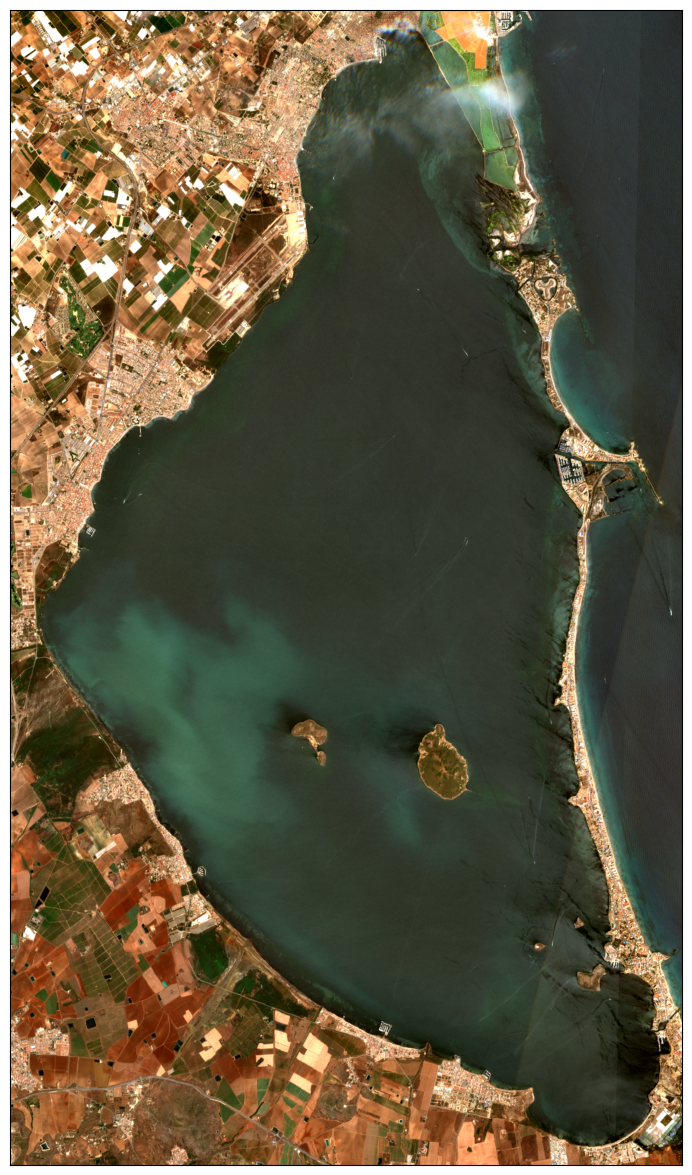

In [69]:
from utils import plot_image

plot_image(image, factor=3 / 255, clip_range=(0, 1))